# **Apartment Hunter**

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

## 1. **EDA (Cleaning and traitment)**

### Get dataset, missing values, duplicates, general infos

In [9]:
df = pd.read_csv("data/raw/kc_house_data.csv", sep=",")

print(f"\nDimensions of the raw dataset : {df.shape}")

# Verification of missing values
print("\nMissing values per columns :")
print(df.isnull().sum())
# Traitment of missing values = No need to do


# Deleting duplicates
n_before = len(df)
df = df.drop_duplicates()
print(f"\nDropped duplicates : {n_before - len(df)}")

print("\nTypes of columns :")
print(df.info())

print("\nPreview of the opening lines :")
print(df.head())


Dimensions of the raw dataset : (21613, 21)

Missing values per columns :
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Dropped duplicates : 0

Types of columns :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqf

### Standardization columns (names and types)

In [10]:
df_new = df.drop('date', axis=1)

### Data distribution for visualizing potential outliers

In [11]:
df_new.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Thanks to the `describe` method, no outliers are detected.

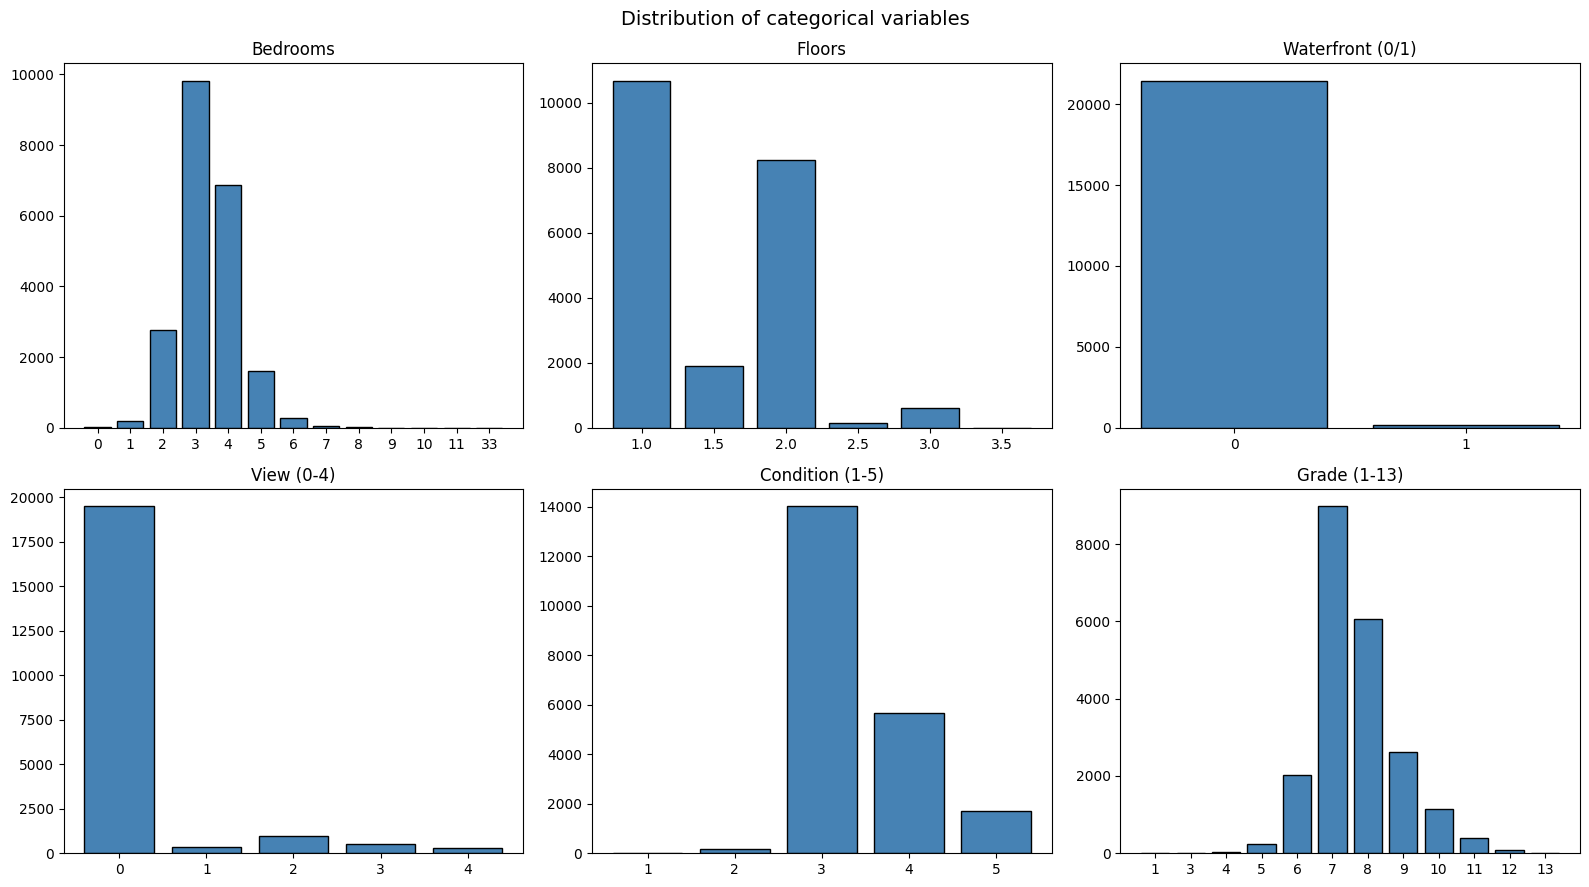

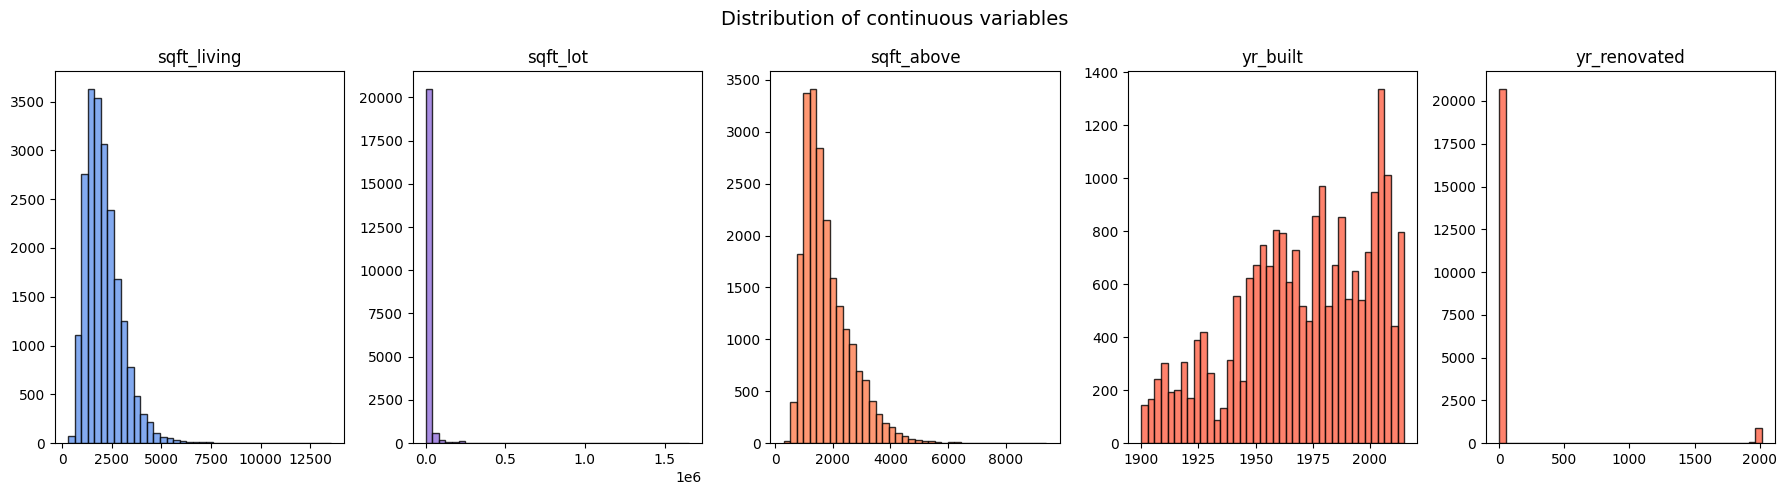

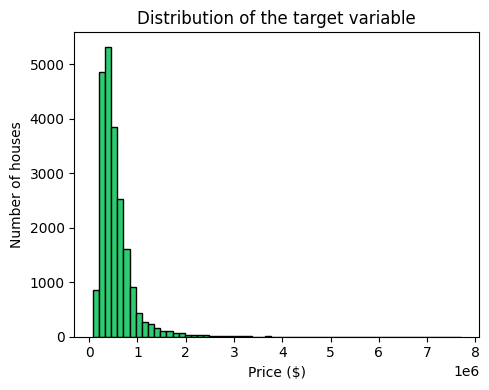

Price statistics : {'count': 21613.0, 'mean': 540088.0, 'std': 367127.0, 'min': 75000.0, '25%': 321950.0, '50%': 450000.0, '75%': 645000.0, 'max': 7700000.0}


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of categorical variables", fontsize=14)

categoricals = ['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']
titles = ['Bedrooms', 'Floors', 'Waterfront (0/1)', 'View (0-4)', 'Condition (1-5)', 'Grade (1-13)']

for ax, col, title in zip(axes.flatten(), categoricals, titles):
    counts = df_new[col].value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(i) for i in counts.index], rotation=0)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Distribution of continuous variables", fontsize=14)
for ax, col, color in zip(axes,
                           ['sqft_living', 'sqft_lot', 'sqft_above', 'yr_built', 'yr_renovated'],
                           ['cornflowerblue', 'mediumpurple', 'coral', 'tomato', 'tomato']):
    ax.hist(df_new[col], bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(col)
plt.tight_layout()
plt.show()



plt.figure(figsize=(5, 4))
plt.hist(df_new['price'], bins=60, color='#2ecc71', edgecolor='black')
plt.title("Distribution of the target variable")
plt.xlabel("Price ($)")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()
print(f"Price statistics : {df_new['price'].describe().round(0).to_dict()}")

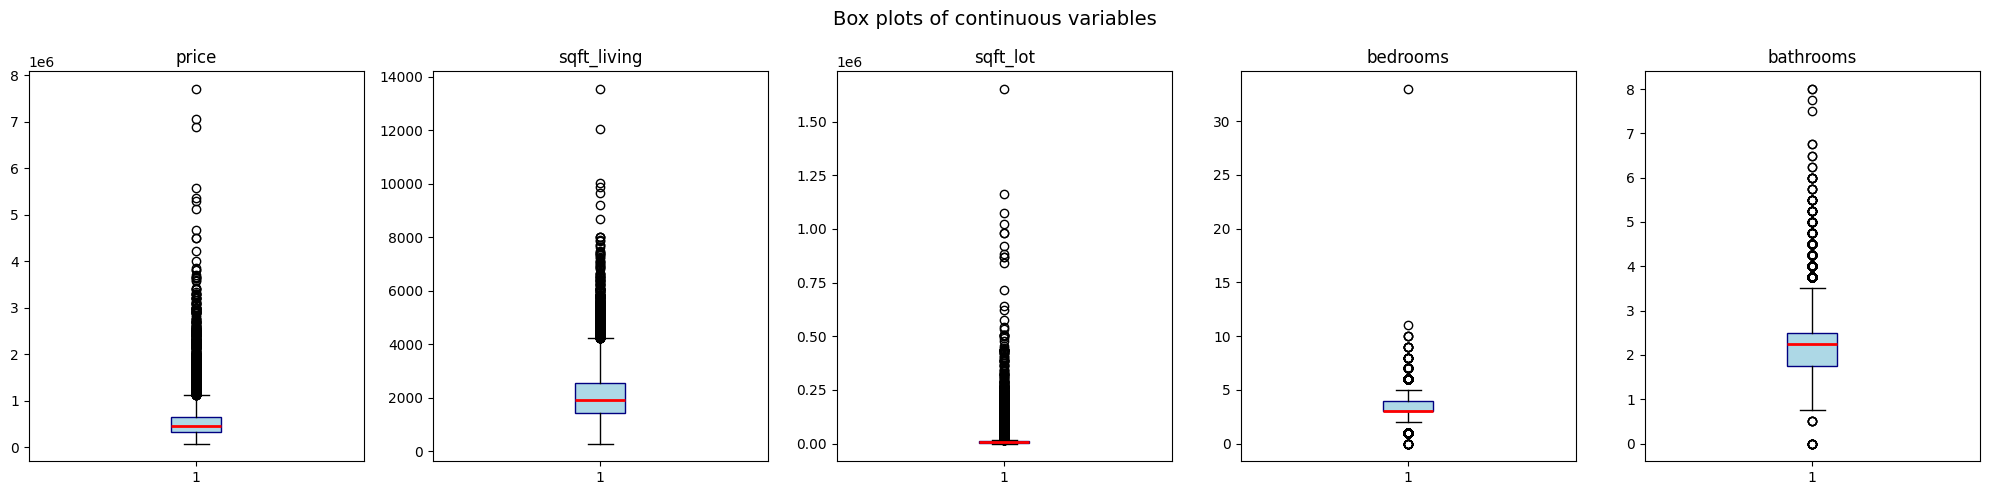

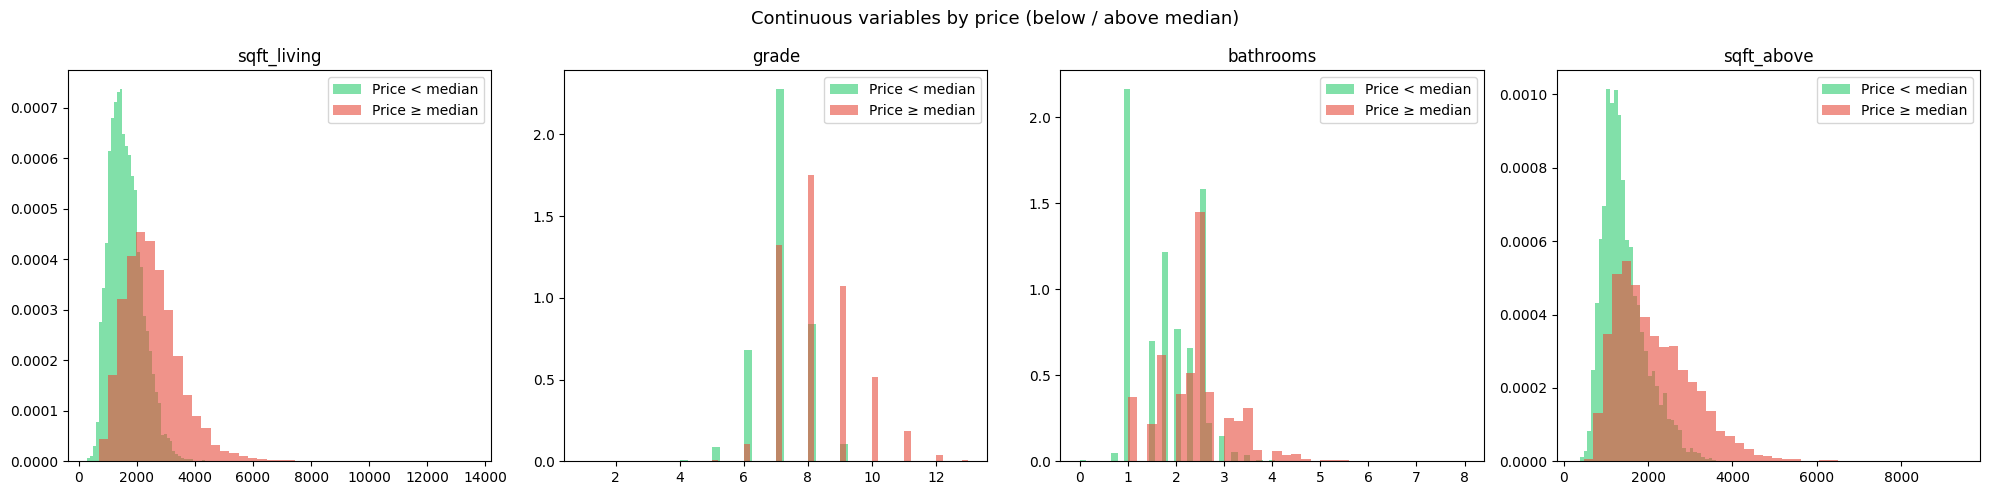

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Box plots of continuous variables", fontsize=14)
for ax, col in zip(axes, ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms']):
    ax.boxplot(df_new[col], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Continuous variables by price (below / above median)",
             fontsize=13)
for ax, col in zip(axes, ['sqft_living', 'grade', 'bathrooms', 'sqft_above']):
    for val, label, color in [(False, 'Price < median', '#2ecc71'), (True, 'Price ≥ median', '#e74c3c')]:
        ax.hist(df_new[(df_new['price'] >= df_new['price'].median()) == val][col], bins=40,
                alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

### Saving in clean folder

In [14]:
os.makedirs("data/clean", exist_ok=True)

df_new.to_csv("data/clean/kc_house_data_clean.csv", index=False)

print("\nSaved in clean folder.")


Saved in clean folder.
